In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import matplotlib.dates as mdates

random.seed(42)

In [2]:
df = pd.read_csv('dataset.csv')
forecasts = pd.read_csv('forecasts.csv')
metrics = pd.read_csv('metrics.csv')

In [3]:
df

,unique_id,ds,y
0,T353,1905-07-01 12:00:00,2261.0
1,T353,1905-08-01 12:00:00,2715.0
2,T353,1905-09-01 12:00:00,2534.0
3,T353,1905-10-01 12:00:00,15900.0
4,T353,1905-11-01 12:00:00,2383.0
...,...,...,...
46195,T47898,2017-05-01 12:00:00,4090.0
46196,T47898,2017-06-01 12:00:00,4070.0
46197,T47898,2017-07-01 12:00:00,4030.0
46198,T47898,2017-08-01 12:00:00,3960.0


In [4]:
forecasts

,unique_id,ds,AutoETS,AutoTheta,Naive,SeasonalNaive,CatBoostRegressor,PatchTST,AutoETS_Standard,AutoTheta_Standard,...,Naive_Robust,SeasonalNaive_Robust,CatBoostRegressor_Robust,PatchTST_Robust,AutoETS_QuantileTransformer,AutoTheta_QuantileTransformer,Naive_QuantileTransformer,SeasonalNaive_QuantileTransformer,CatBoostRegressor_QuantileTransformer,PatchTST_QuantileTransformer
0,T10288,2015-06-01 12:00:00,1991.6772,1967.4970,1992.9,1710.5,1918.488900,1979.2539,1991.1736,1966.8362,...,1992.9,1710.5000,1918.487585,2028.1841,1992.8944,1973.7825,1992.9000,1710.5000,1954.756016,1970.3182
1,T10288,2015-07-01 12:00:00,1991.6772,1965.1971,1992.9,1705.5,1922.223577,1949.1136,1991.1736,1967.3433,...,1992.9,1705.5000,1922.222233,2021.6471,1992.8944,1971.0164,1992.9000,1705.5000,1913.064402,1969.1649
2,T10288,2015-08-01 12:00:00,1991.6772,1975.7216,1992.9,1692.5,1875.765481,1936.6210,1991.1736,1975.8264,...,1992.9,1692.5000,1875.764163,2045.7562,1992.8944,1979.8865,1992.9000,1692.5000,1882.393747,2002.7233
3,T10288,2015-09-01 12:00:00,1991.6772,1990.8214,1992.9,1705.8,1863.960163,1928.8679,1991.1736,1987.8494,...,1992.9,1705.8000,1863.958793,2031.8425,1992.8944,1991.1184,1992.9000,1705.8000,1853.487086,1987.8812
4,T10288,2015-10-01 12:00:00,1991.6772,1978.8950,1992.9,1766.3,1908.158386,1926.8425,1991.1736,1977.7876,...,1992.9,1766.3000,1908.156993,2013.6846,1992.8944,1980.4666,1992.9000,1766.2999,1856.194300,1981.5204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,T9633,2016-12-01 12:00:00,2352.5154,1769.0902,2080.0,1920.0,2036.595303,2126.6938,2257.2964,1585.9397,...,2080.0,1920.0000,2036.594158,2098.7485,2249.7640,1862.7323,2079.9998,1920.0000,1980.244927,2077.1797
3596,T9633,2017-01-01 12:00:00,2371.9814,1746.9486,2080.0,1890.0,2036.595303,2135.8643,2264.0234,1550.7253,...,2080.0,1890.0000,2036.594158,2105.4380,2255.5078,1851.4447,2079.9998,1889.9999,1957.391753,2061.5596
3597,T9633,2017-02-01 12:00:00,2391.4473,1724.8071,2080.0,1870.0,2036.228096,2115.3806,2270.2402,1515.5107,...,2080.0,1869.9999,2036.226940,2102.5413,2259.4229,1841.3156,2079.9998,1870.0000,1957.391753,2045.1571
3598,T9633,2017-03-01 12:00:00,2410.9130,1702.6655,2080.0,1850.0,2036.228096,2099.3123,2275.9860,1480.2964,...,2080.0,1850.0000,2036.226940,2090.3203,2260.3850,1832.1523,2079.9998,1850.0000,1957.391753,2065.6873


Полученные метрики из экспериментов:

In [ ]:
pd.set_option('display.max_rows', None)
print(metrics.round(2)) # принтом, потому что иначе у меня все равно обрезается вывод почему-то

                                    model  smape     mae     rmse
0                                 AutoETS   3.40  661.82  1638.51
1                               AutoTheta   3.35  626.77  1440.77
2                                   Naive   3.74  736.23  1614.13
3                           SeasonalNaive   4.10  783.70  1638.15
4                       CatBoostRegressor   3.81  730.90  1550.16
5                                PatchTST   3.77  714.47  1508.53
6                        AutoETS_Standard   3.35  615.75  1350.98
7                      AutoTheta_Standard   3.46  646.53  1464.72
8                          Naive_Standard   3.74  736.23  1614.13
9                  SeasonalNaive_Standard   4.10  783.70  1638.15
10             CatBoostRegressor_Standard   3.81  730.90  1550.16
11                      PatchTST_Standard   3.50  663.81  1449.62
12                         AutoETS_Robust   3.41  617.53  1343.28
13                       AutoTheta_Robust   3.43  641.12  1460.88
14        

In [6]:
def plot_forecasts(series_id, model_list, model_name, horizon=18):
    series = df[df['unique_id'] == series_id].sort_values('ds')
    preds = forecasts[forecasts['unique_id'] == series_id].sort_values('ds')

    train = series.iloc[:-horizon]
    test = series.iloc[-horizon:]

    plt.figure(figsize=(20, 6))

    plt.plot(train['ds'], train['y'], label='Train', color='blue', linewidth=2)
    plt.plot(test['ds'], test['y'], label='Test', color='red', linewidth=2)

    colors = ['green', 'orange', 'purple', 'brown', 'pink', 'gray']
    for i, model in enumerate(model_list):
        if model in preds.columns:
            plt.plot(
                preds['ds'], 
                preds[model], 
                linestyle='--', 
                marker='o',
                markersize=4,
                label=model,
                color=colors[i % len(colors)]
            )
    # чтобы даты адекватно отображались
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    

    plt.title(f"{model_name} ряд {series_id}")
    plt.xlabel("Дата")
    plt.ylabel("Значение")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [7]:
# отберу по моделям, чтобы дальше было удобней
models = metrics['model'].tolist()
models_naive = [m for m in models if m.startswith('Naive')]
models_seasonal_naive = [m for m in models if m.startswith('SeasonalNaive')]
models_ets = [m for m in models if m.startswith('AutoETS')]
models_theta = [m for m in models if m.startswith('AutoTheta')]
models_cat = [m for m in models if m.startswith('CatBoostRegressor')]
models_patch = [m for m in models if m.startswith('PatchTST')]
models_div = [models_naive, models_seasonal_naive, models_ets, models_theta, models_cat, models_patch]

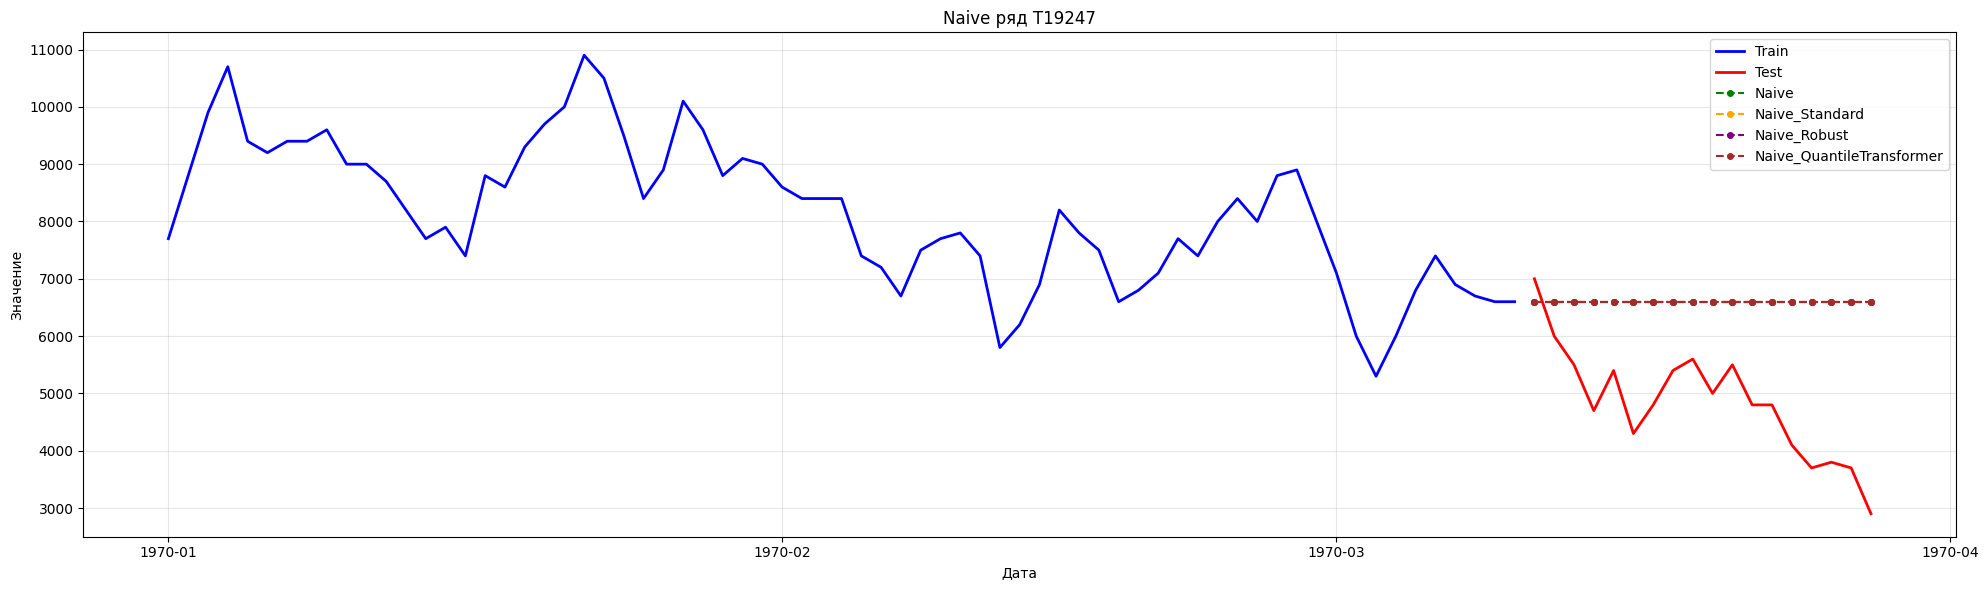

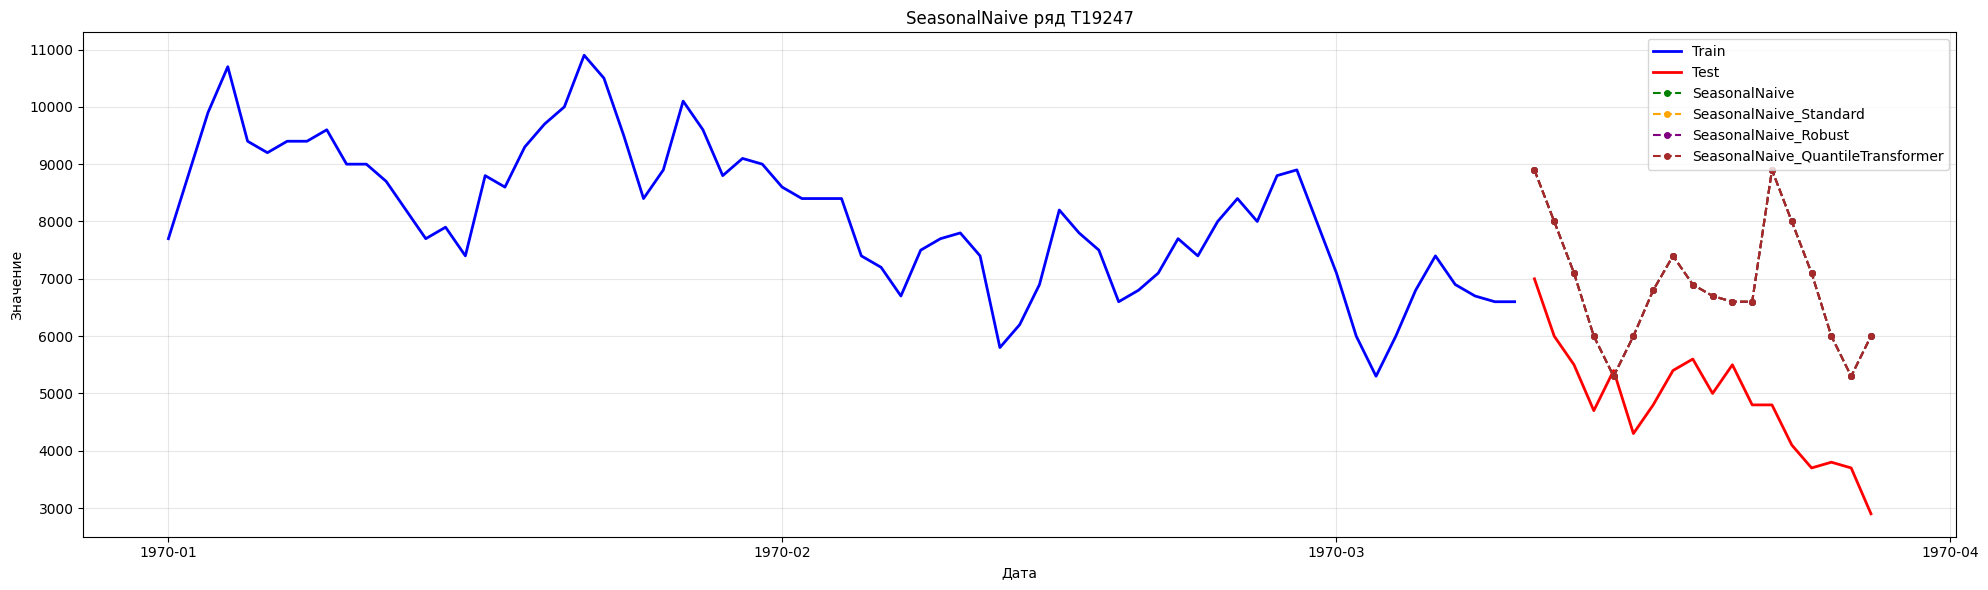

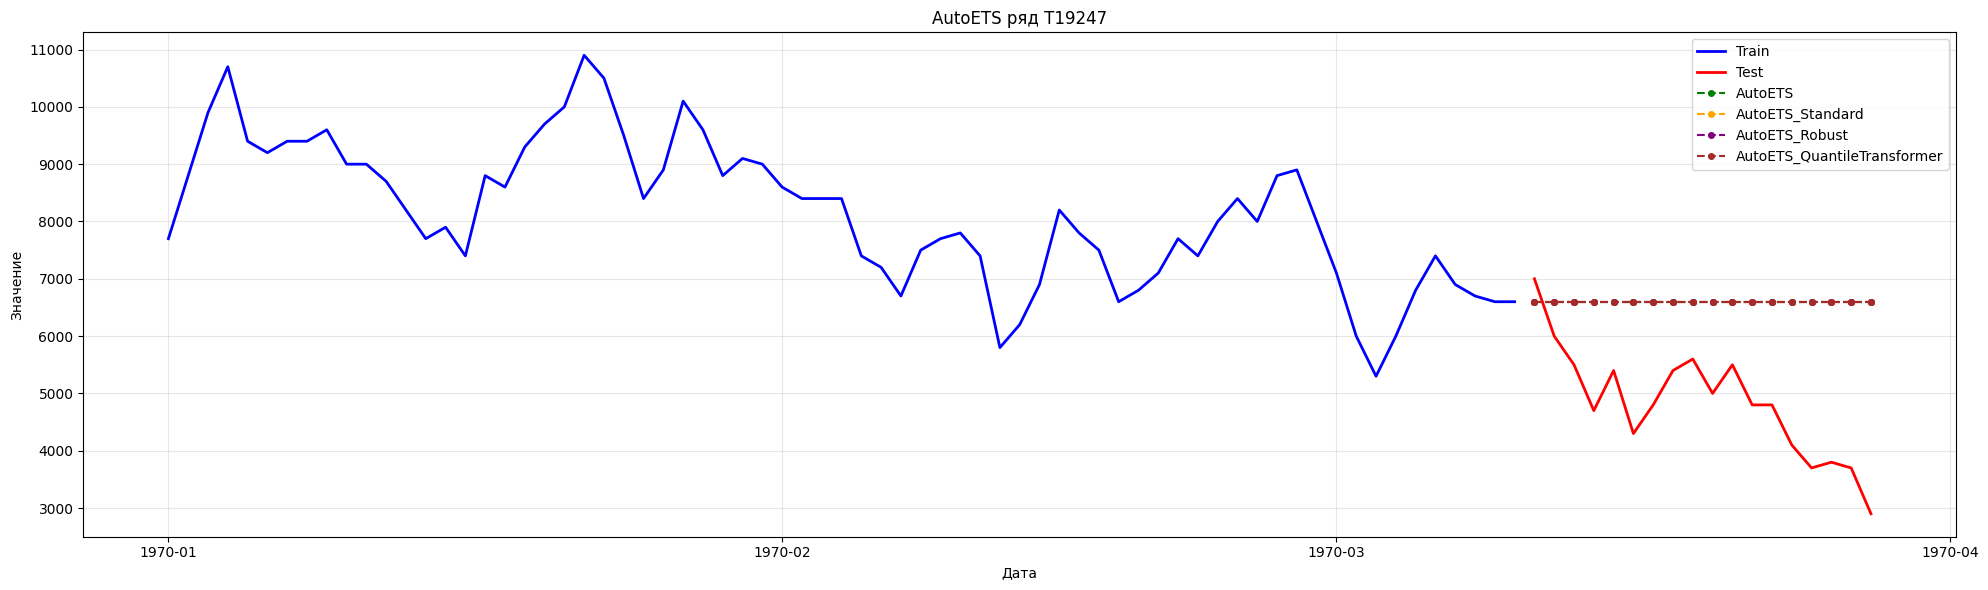

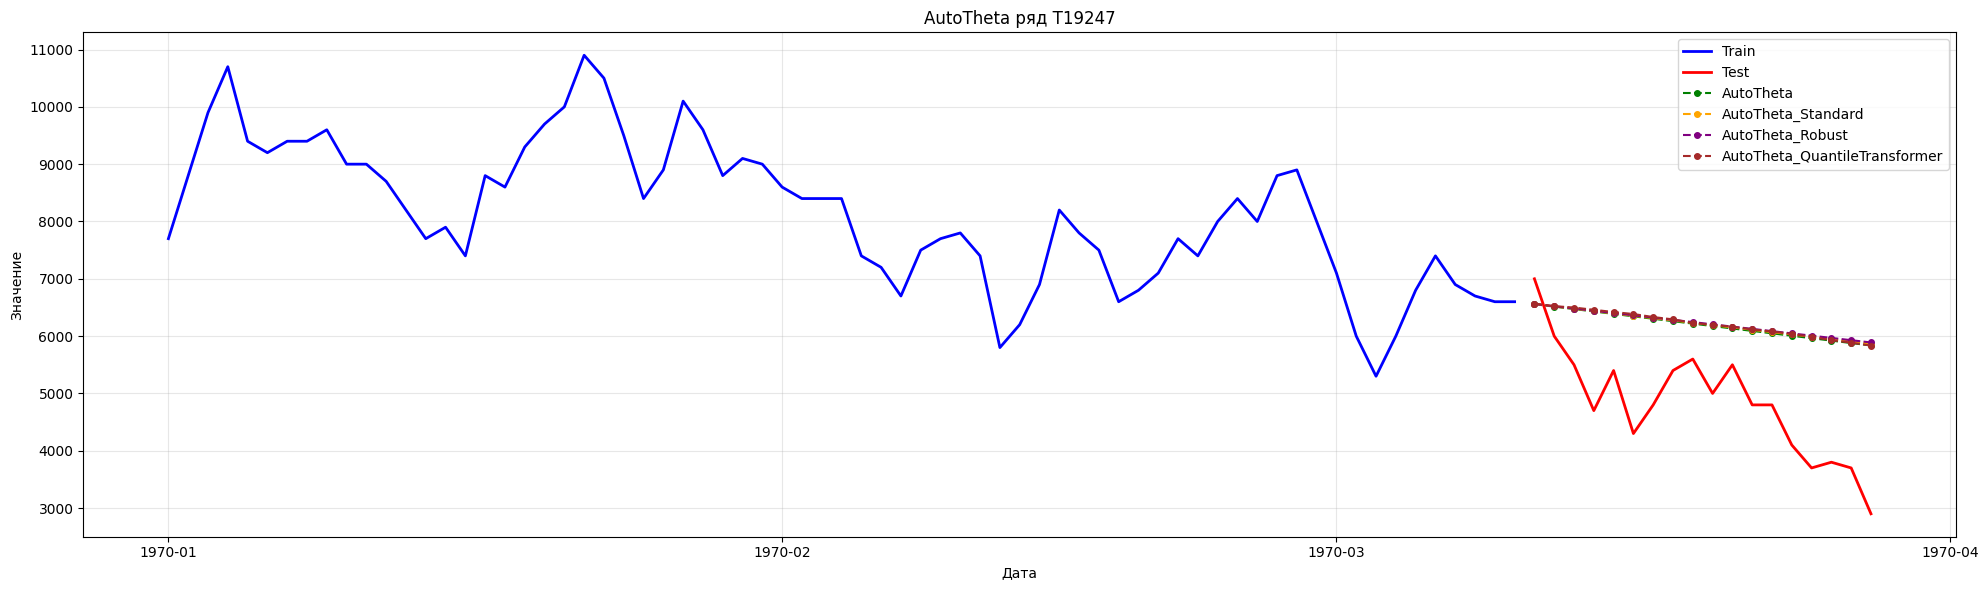

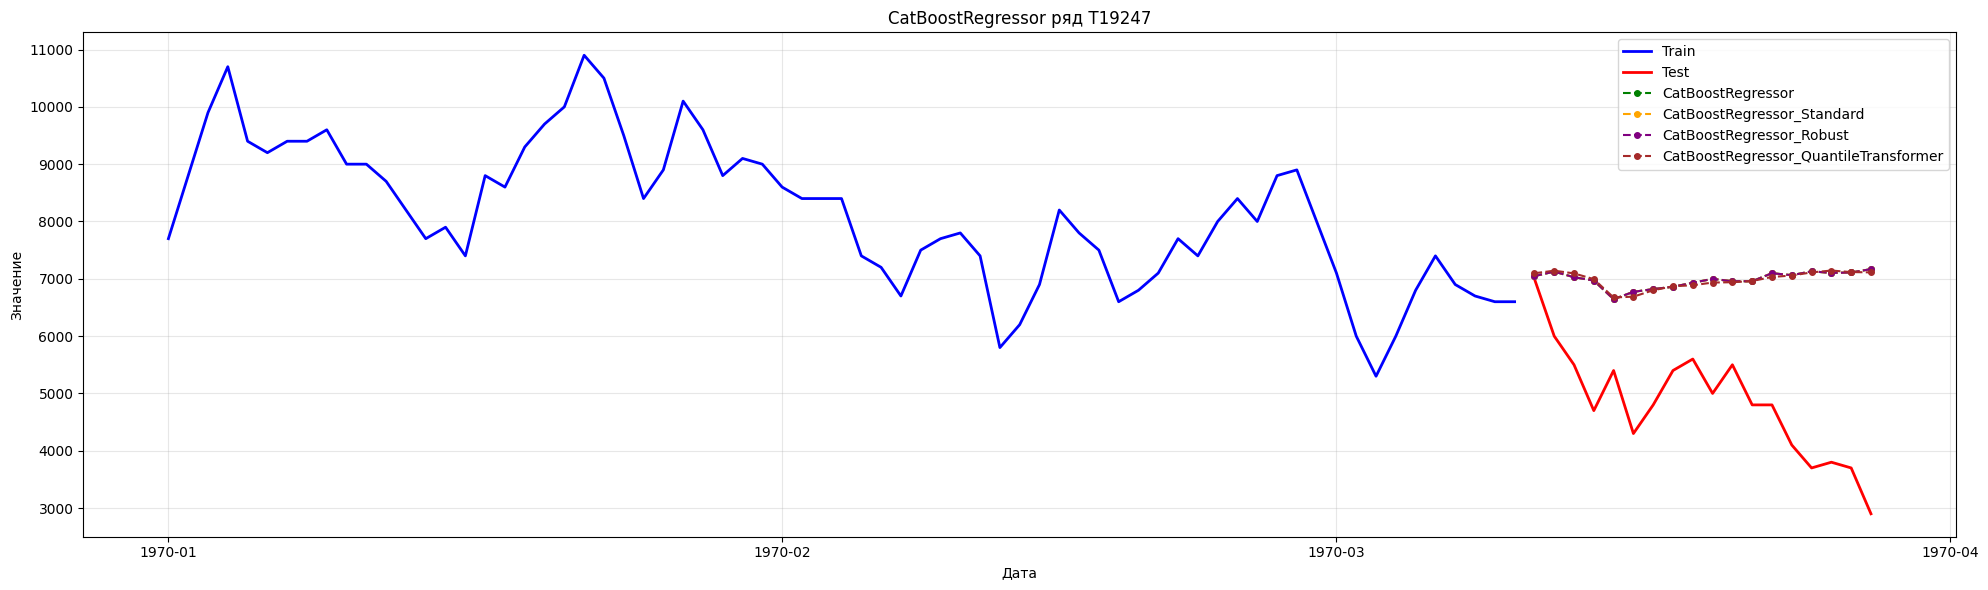

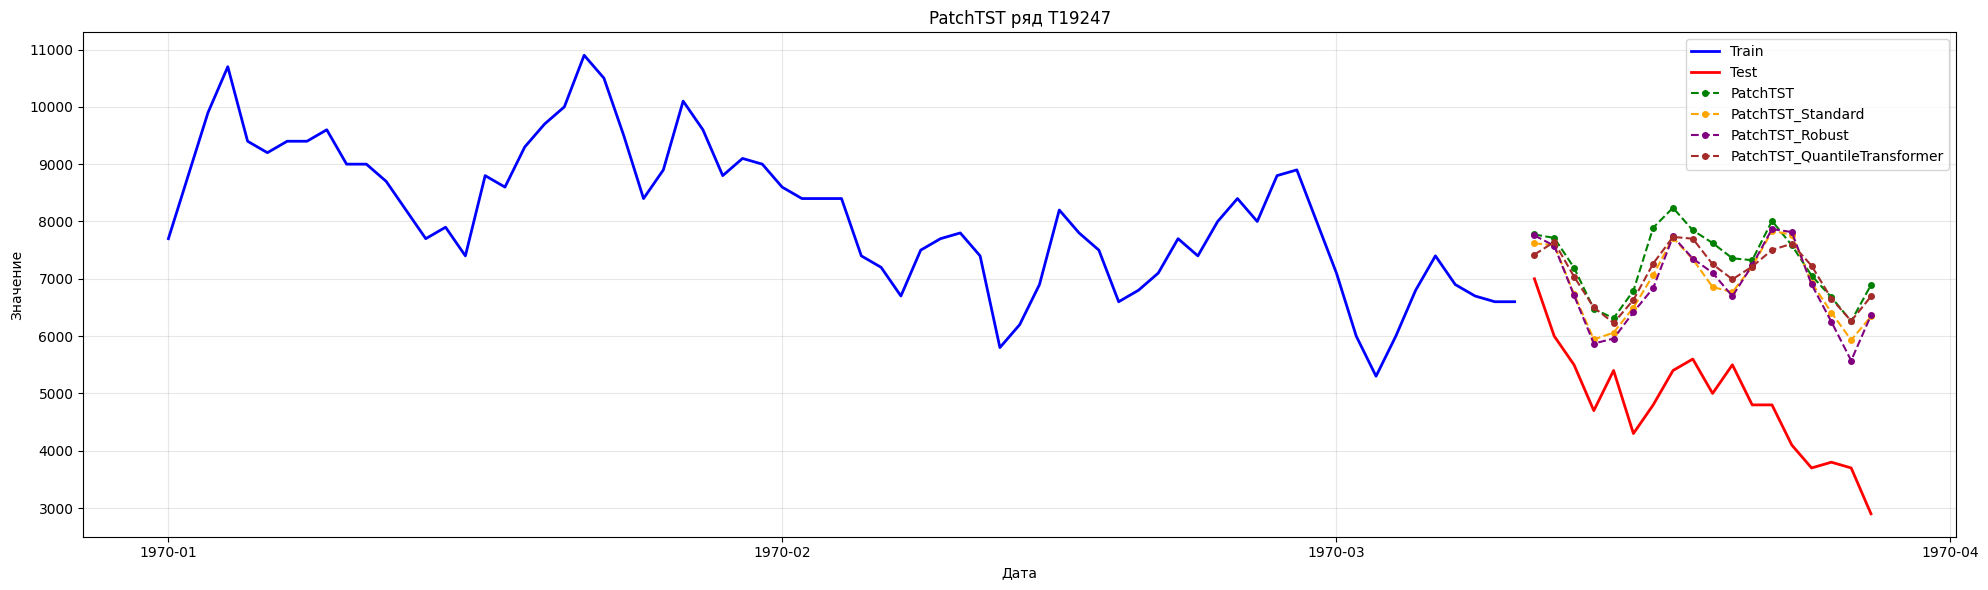

In [12]:
series_id = random.choice(df['unique_id'].unique())

for models_to_plot in models_div:
    plot_forecasts(series_id, models_to_plot, models_to_plot[0].split('_')[0])

Из визуализации прогнозов видно, что для бейзлайн моделей прогнозы практически не меняются от применяемой нормализации. Для Catboost видны небольшие отличия между экспериментами. Для PatchTST различия более заметны.

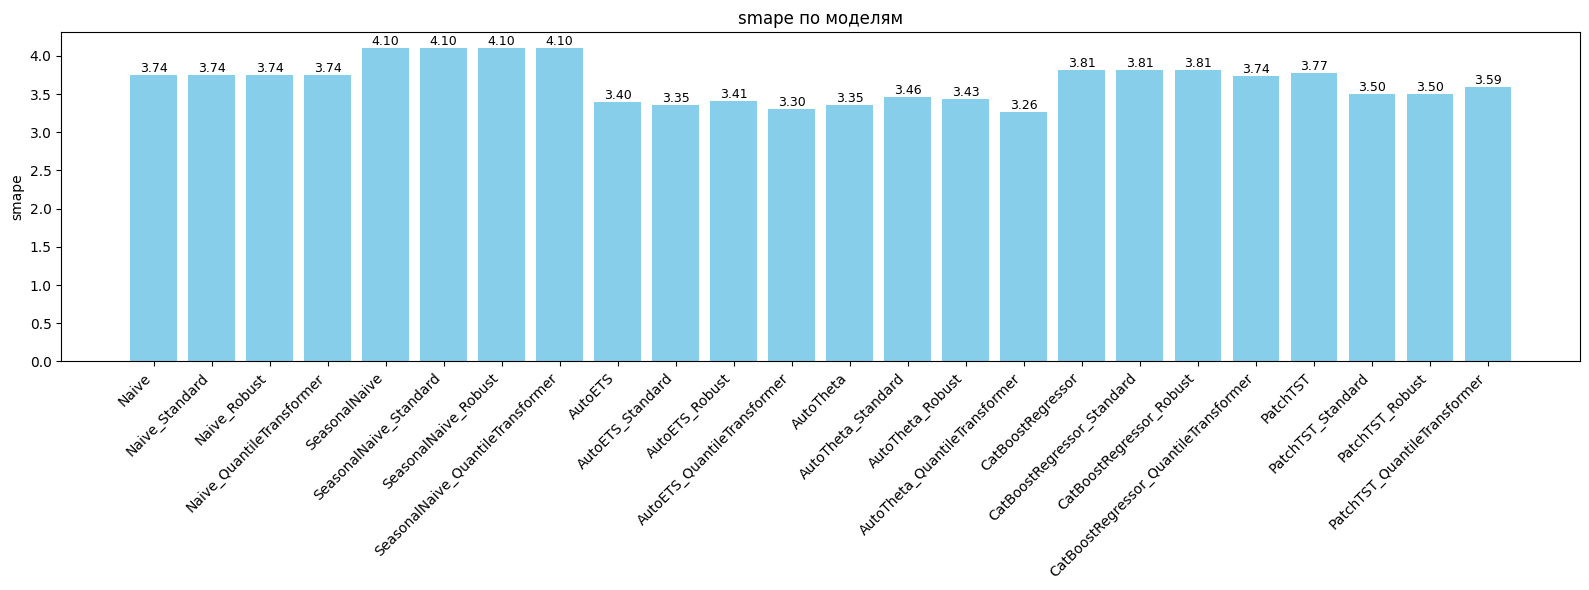

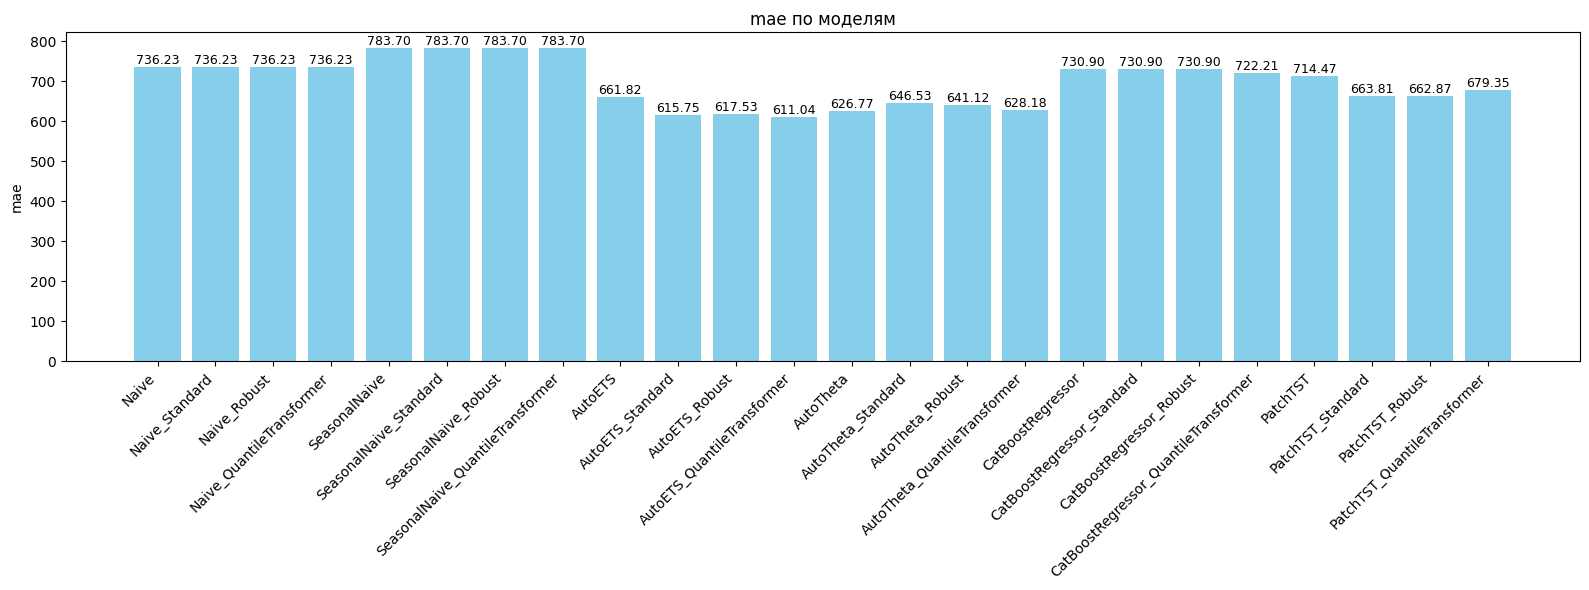

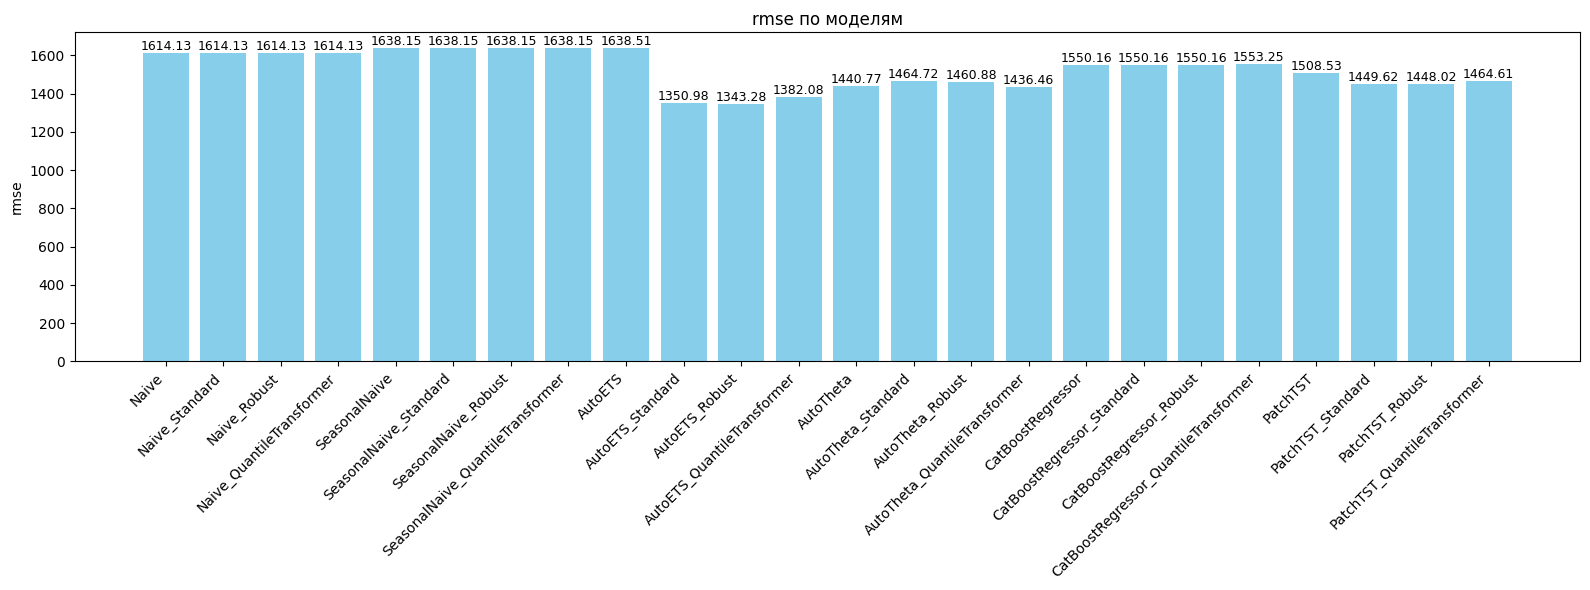

In [11]:
model_order = []
for m in models_div:
    model_order.extend(m)

metrics['model'] = pd.Categorical(metrics['model'], categories=model_order, ordered=True)
metrics = metrics.sort_values('model')

def plot_metric(metric_name):
    plt.figure(figsize=(16,6))
    bars = plt.bar(metrics['model'], metrics[metric_name], color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(metric_name)
    plt.title(f'{metric_name} по моделям')
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

for metric in ['smape', 'mae', 'rmse']:
    plot_metric(metric)

Из сравнения метрик видно, что статичстические модели практически не чувствительны к нормализации, значения метрик остаются почти неизменными. Catboost демонстрирует практически полную инвариантность к нормализации, так как модели на основе деревьев не чувствительны к масштабу признаков. PatchTST показал наибольшую разницу в зависимости от применяемого метода нормализации.

In [12]:
def plot_scaler_comparison(metrics, scaler_name, metric='smape'):

    base = metrics[~metrics['model'].str.contains('_')].copy()
    scaler = metrics[metrics['model'].str.contains(f'_{scaler_name}')].copy()
    scaler['model'] = scaler['model'].str.replace(f'_{scaler_name}', '')
    merged = base.merge(scaler, on='model', suffixes=('_base', f'_{scaler_name}'))
    merged[f'delta_{metric}'] = (merged[f'{metric}_{scaler_name}'] - merged[f'{metric}_base'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].bar(merged['model'], merged[f'{metric}_base'], label='Без нормализации')
    axes[0].bar(merged['model'], merged[f'{metric}_{scaler_name}'], label=f'{scaler_name}Scaler')
    axes[0].set_title(f'{scaler_name}Scaler ({metric})')
    axes[0].set_ylabel(metric)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend()

    axes[1].bar(merged['model'], merged[f'delta_{metric}'])
    axes[1].axhline(0, color='black')
    axes[1].set_title(f'Изменение {metric}')
    axes[1].set_ylabel(f'Изменение {metric}')
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle(f'Влияние {scaler_name}Scaler на модели')
    plt.tight_layout()
    plt.show()

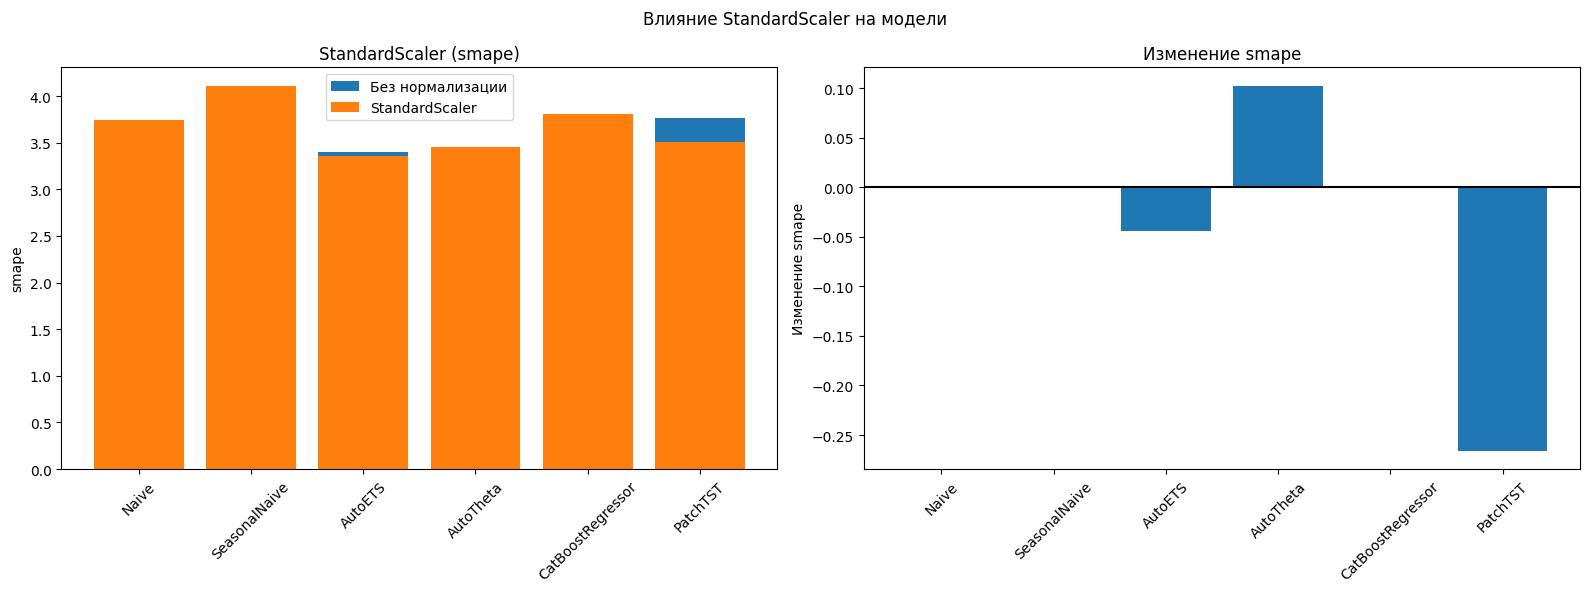

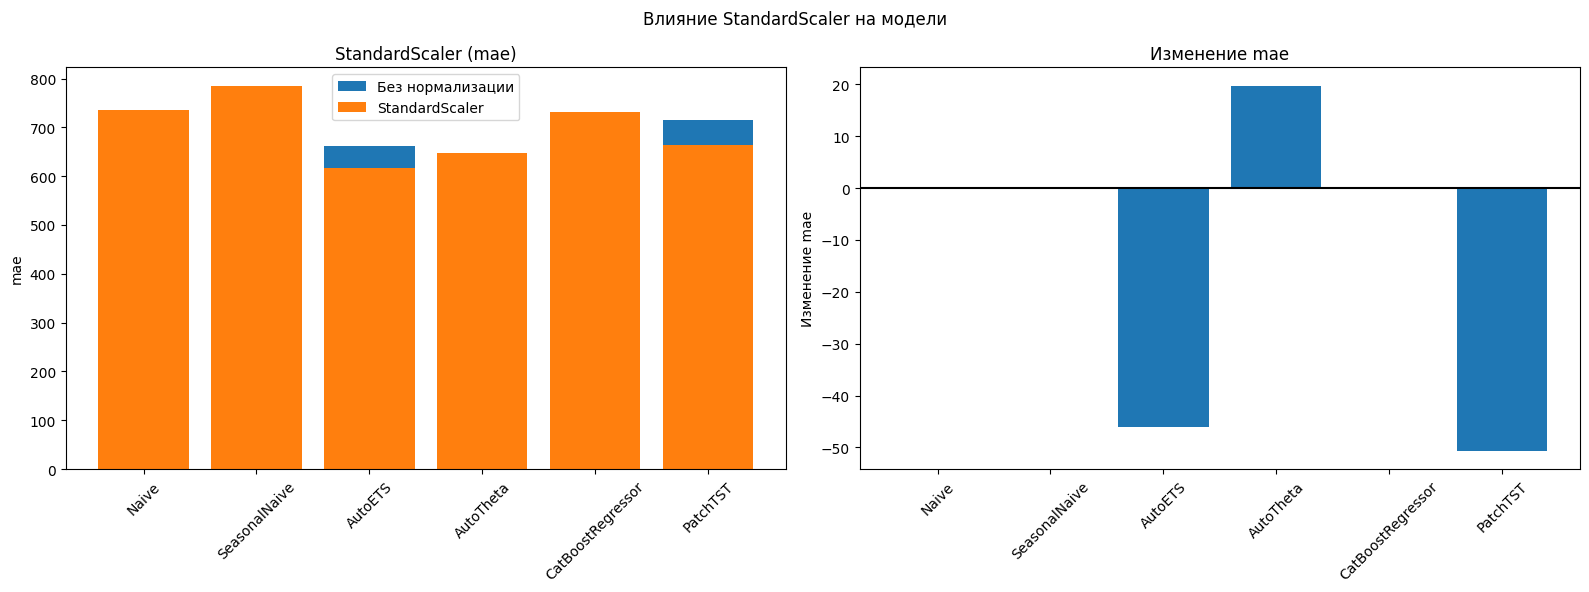

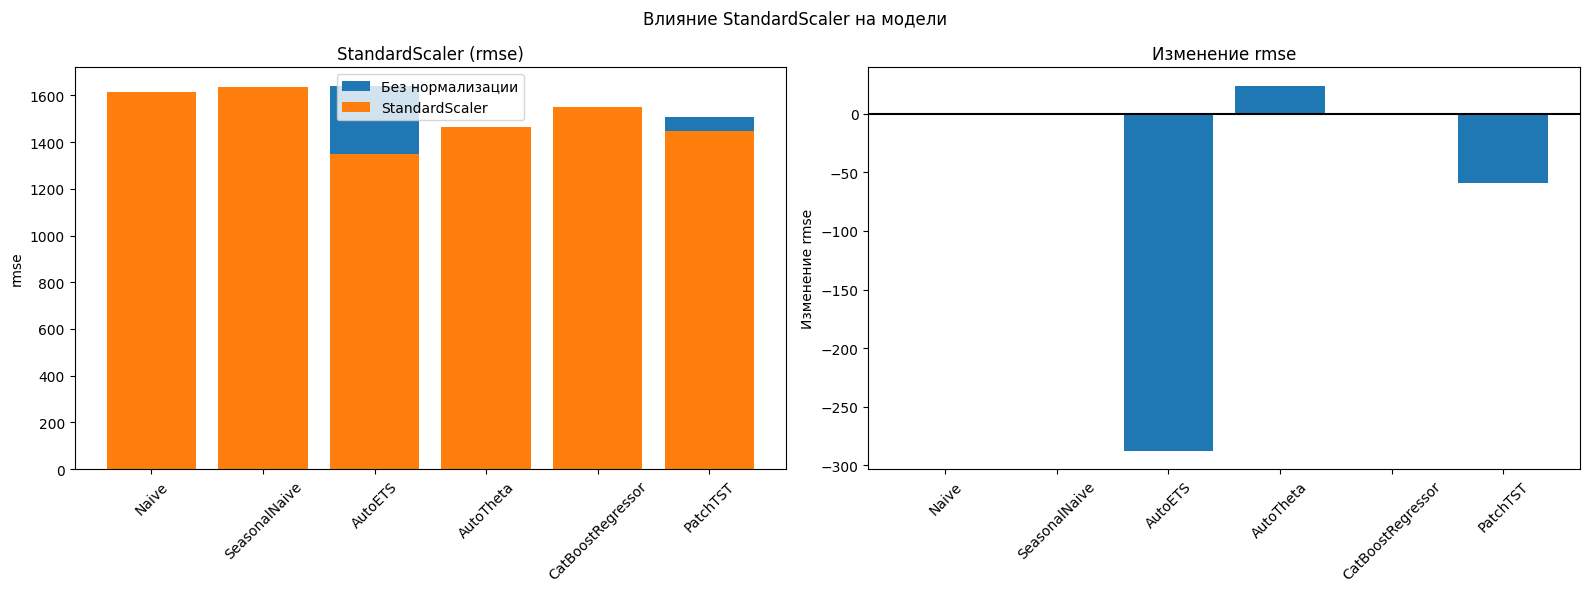

In [13]:
plot_scaler_comparison(metrics, 'Standard', 'smape')
plot_scaler_comparison(metrics, 'Standard', 'mae')
plot_scaler_comparison(metrics, 'Standard', 'rmse')

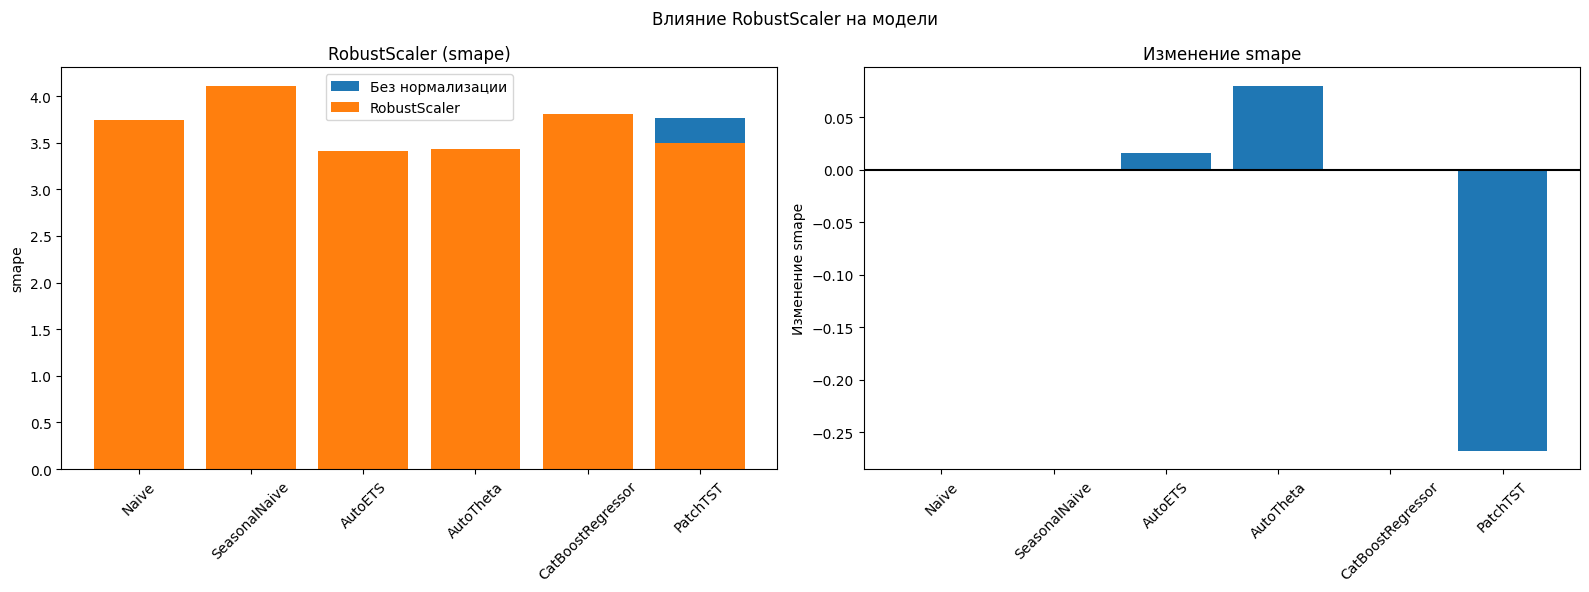

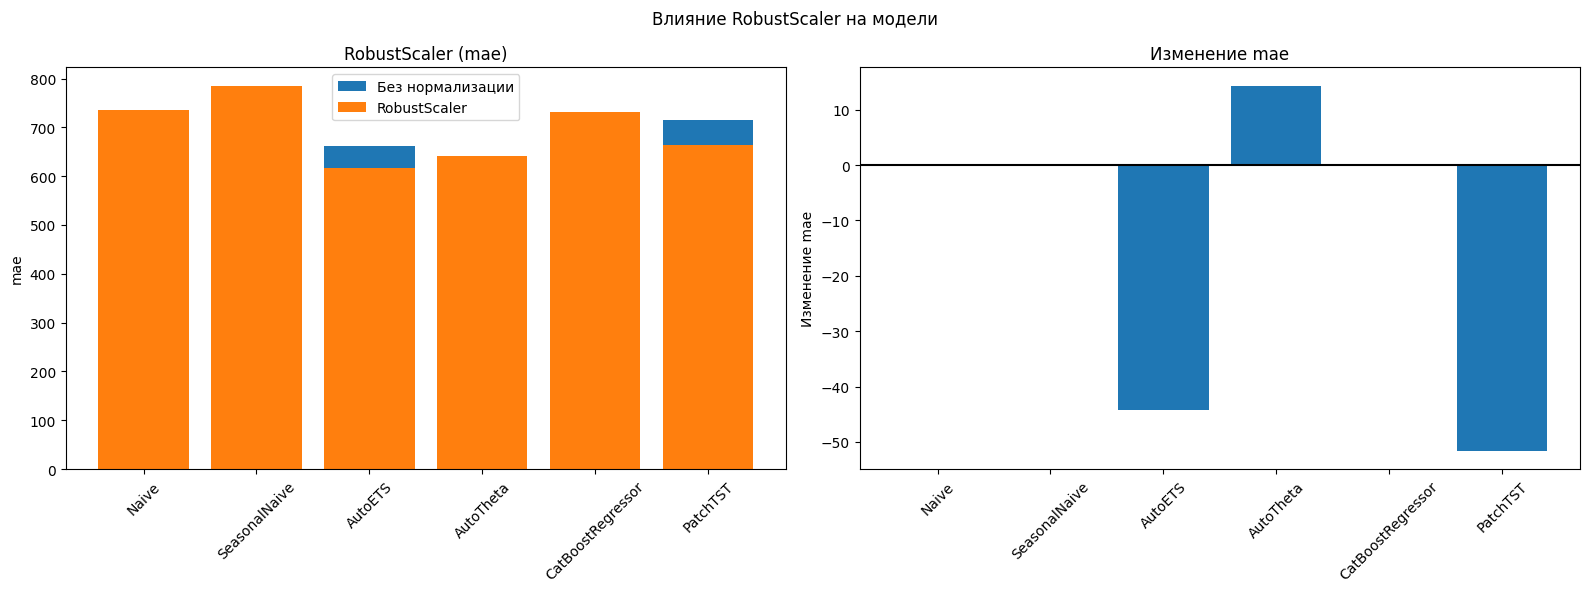

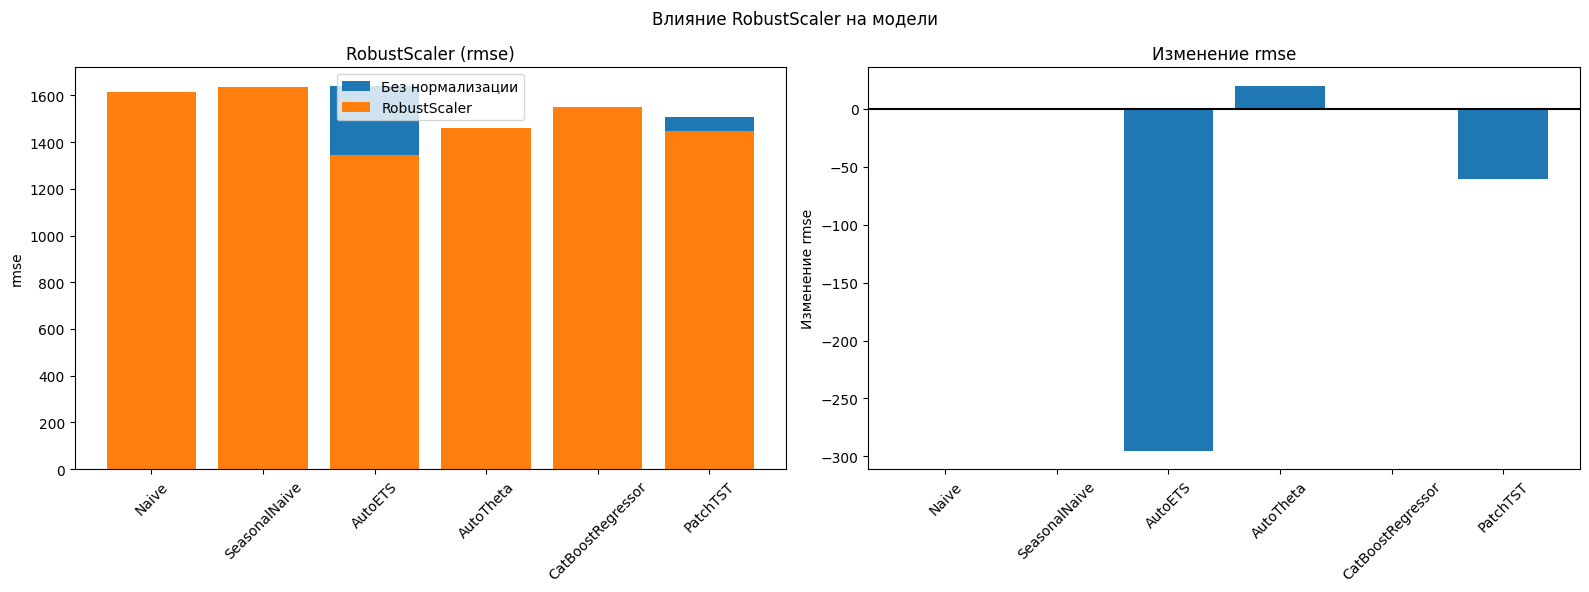

In [14]:
plot_scaler_comparison(metrics, 'Robust', 'smape')
plot_scaler_comparison(metrics, 'Robust', 'mae')
plot_scaler_comparison(metrics, 'Robust', 'rmse')

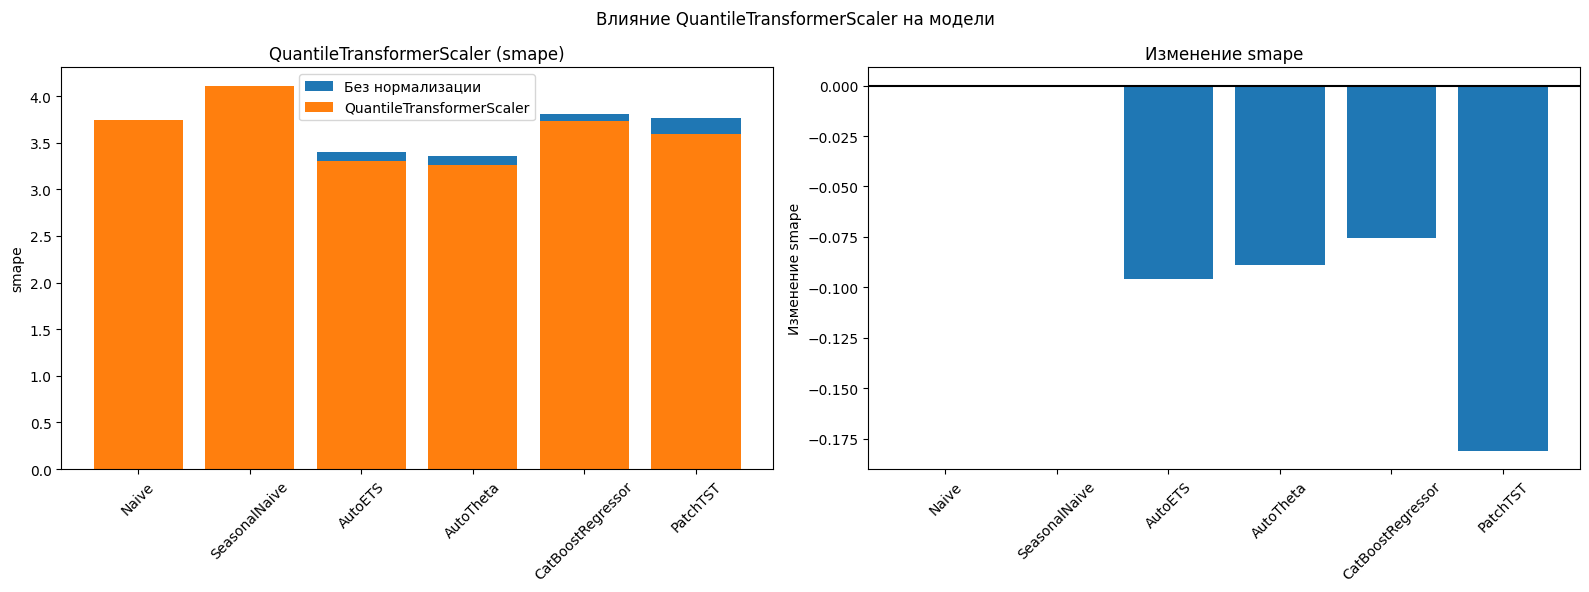

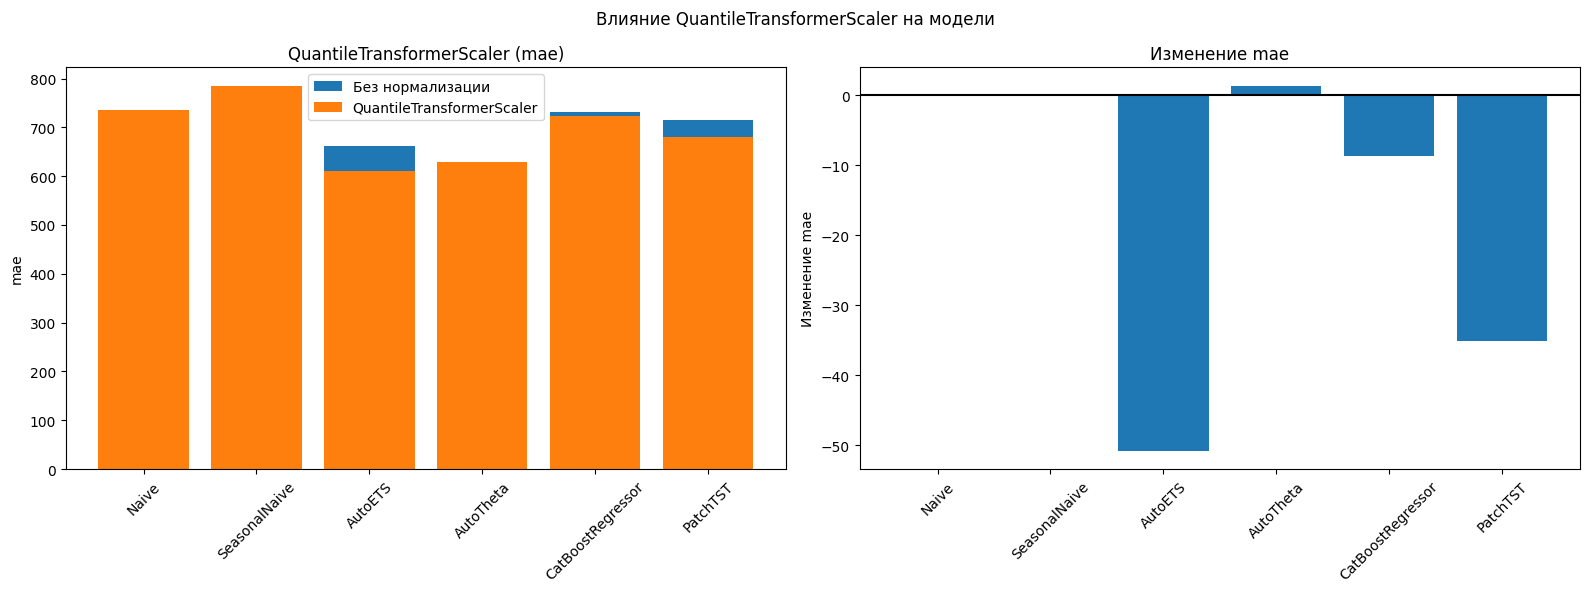

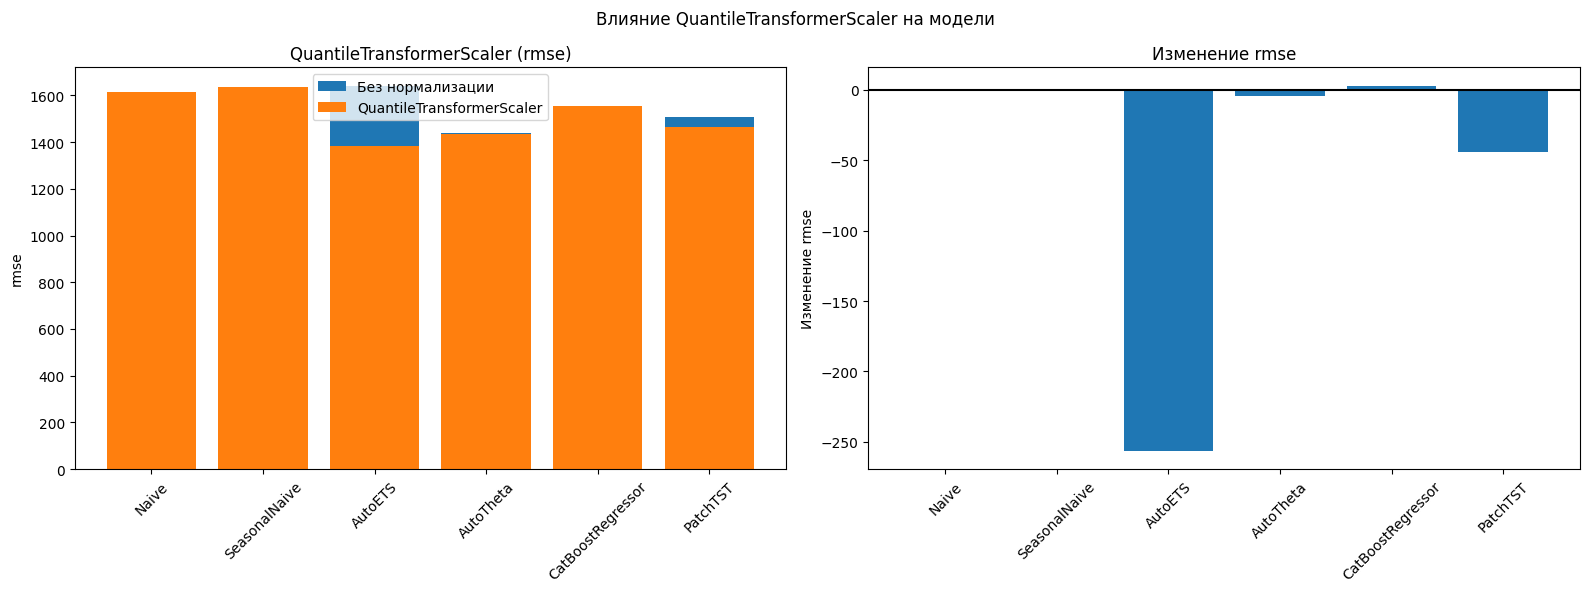

In [15]:
plot_scaler_comparison(metrics, 'QuantileTransformer', 'smape')
plot_scaler_comparison(metrics, 'QuantileTransformer', 'mae')
plot_scaler_comparison(metrics, 'QuantileTransformer', 'rmse')

В ходе работы, было исследовано влияние нормализации временных рядов на качество моделей разных классов: статистических, моделей машинного обучения и нейронных сетей. Статистические практически не чувствительны к нормализации, однако AutoETS аоказало значительную зависимость от нормализации. Модель Catboost продемонстрировала устойчивость к масштабу признаков. PatchTST существенно зависит от нормализации входных данных.